## `crossmatch.ipynb`
--------------------

This notebook does crossmatching between the sampled DESI catalog and HSC. This is mostly for inspection purposes.

In [1]:
## Imports
import numpy as np
import glob
import matplotlib.pyplot as plt
import os
import fitsio as fio

from pathlib import Path
from astropy import units as u
from astropy.coordinates import SkyCoord, match_coordinates_sky
from astropy.io import fits
from astropy.table import Table

In [2]:
USER_ROOT = Path("/global/cfs/cdirs/desicollab/users/jchdj")
DATA_ROOT = USER_ROOT / "desi-y3-hsc" / "data"
DESI_ROOT = DATA_ROOT / "desi" / "cat"
HSC_ROOT = DATA_ROOT / "hsc" / "cat"
XMATCH_ROOT = DATA_ROOT / "xmatch"

# Find the desi file
desi_file = Path(DESI_ROOT, "desiy3_cut_cat.fits")
print(f"DESI sampled catalog : {desi_file}")

# Find HSC data
hsc_file = Path(HSC_ROOT, "hscy3_cat.fits")
print(f"HSC catalog : {hsc_file}")

print(f"Saving cross-matched catalog to : {XMATCH_ROOT}")

DESI sampled catalog : /global/cfs/cdirs/desicollab/users/jchdj/desi-y3-hsc/data/desi/cat/desiy3_cut_cat.fits
HSC catalog : /global/cfs/cdirs/desicollab/users/jchdj/desi-y3-hsc/data/hsc/cat/hscy3_cat.fits
Saving cross-matched catalog to : /global/cfs/cdirs/desicollab/users/jchdj/desi-y3-hsc/data/xmatch


In [3]:
# Read the HSC catalog (ETA ~ 2s)
hsc = fio.read(hsc_file)

In [4]:
# Read the DESI catalog (ETA ~ 20-30s)
desi = fio.read(desi_file)

In [5]:
print("Loading HSC coordinates")
coords_hsc = SkyCoord(ra=hsc["RA"], dec=hsc["Dec"], unit=(u.deg, u.deg), frame="icrs")
print("Loading DESI coordinates")
coords_desi = SkyCoord(
    ra=desi["TARGET_RA"], dec=desi["TARGET_DEC"], unit=(u.deg, u.deg), frame="icrs"
)

Loading HSC coordinates
Loading DESI coordinates


In [6]:
# Perform the crossmatch, assuming HSC is deeper than DESI (ETA ~ 1min)
idx, d2d, _ = coords_desi.match_to_catalog_sky(coords_hsc)

In [7]:
# Setting a maximum separation of 0.2 arcsec between two targets when crossmatching
max_sep = 0.8 * u.arcsec
sep_constraint = d2d < max_sep

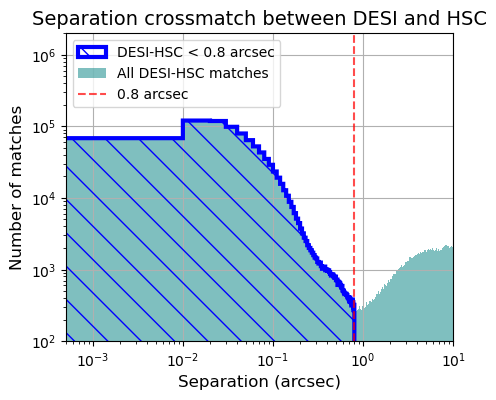

In [8]:
# Plotting separation histogram based on the crossmatch
plt.figure(figsize=(5, 4))
xmatch_bins = np.linspace(0, 50, 5000)
plt.hist(
    d2d[sep_constraint].arcsec,
    bins=xmatch_bins,
    alpha=1,
    histtype="step",
    color="blue",
    hatch="\\",
    linewidth=3,
    label=f"DESI-HSC < {max_sep}",
)
plt.hist(
    d2d.arcsec, bins=xmatch_bins, alpha=0.5, color="teal", label="All DESI-HSC matches"
)
plt.axvline(
    max_sep.to(u.arcsec).value,
    color="red",
    linestyle="--",
    label=f"{max_sep}",
    alpha=0.7,
)
plt.xlabel("Separation (arcsec)", fontsize=12)
plt.ylabel("Number of matches", fontsize=12)
plt.title("Separation crossmatch between DESI and HSC", fontsize=14)
plt.xscale("log")
plt.yscale("log")
plt.xlim(5e-4, 1e1)
plt.ylim(1e2, 2e6)
plt.legend(fontsize=10, loc="upper left")
plt.grid()

In [9]:
# Getting the matched coordinates between the two catalogs
coords_xmatch_desi = coords_desi[sep_constraint]
coords_xmatch_hsc = coords_hsc[idx[sep_constraint]]
print(len(coords_xmatch_desi), "DESI targets matched with HSC")
print(len(coords_xmatch_hsc), "HSC targets matched with DESI")

879249 DESI targets matched with HSC
879249 HSC targets matched with DESI


In [11]:
desi_xmatch_file = Path(XMATCH_ROOT, "desi_xm_hsc_sep0_8.fits")
hsc_xmatch_file = Path(XMATCH_ROOT, "hsc_xm_desi_sep0_8.fits")

In [12]:
desi_xmatch = Table(desi[sep_constraint])
hsc_xmatch = Table(hsc[idx[sep_constraint]])

In [13]:
desi_xmatch["HSC_ROW_MATCH"] = idx[sep_constraint]
hsc_xmatch["DESI_ROW_MATCH"] = np.flatnonzero(sep_constraint)

hsc_xmatch.write(hsc_xmatch_file, overwrite=True)
print(f"HSC matched catalog saved to {hsc_xmatch_file}")
desi_xmatch.write(desi_xmatch_file, overwrite=True)
print(f"DESI matched catalog saved to {desi_xmatch_file}")

HSC matched catalog saved to /global/cfs/cdirs/desicollab/users/jchdj/desi-y3-hsc/data/xmatch/hsc_xm_desi_sep0_8.fits
DESI matched catalog saved to /global/cfs/cdirs/desicollab/users/jchdj/desi-y3-hsc/data/xmatch/desi_xm_hsc_sep0_8.fits


In [14]:
ra_desi = coords_xmatch_desi.ra.rad
dec_desi = coords_xmatch_desi.dec.rad
ra_hsc = coords_xmatch_hsc.ra.rad
dec_hsc = coords_xmatch_hsc.dec.rad

Finished plotting DESI coordinates
Finished plotting HSC coordinates


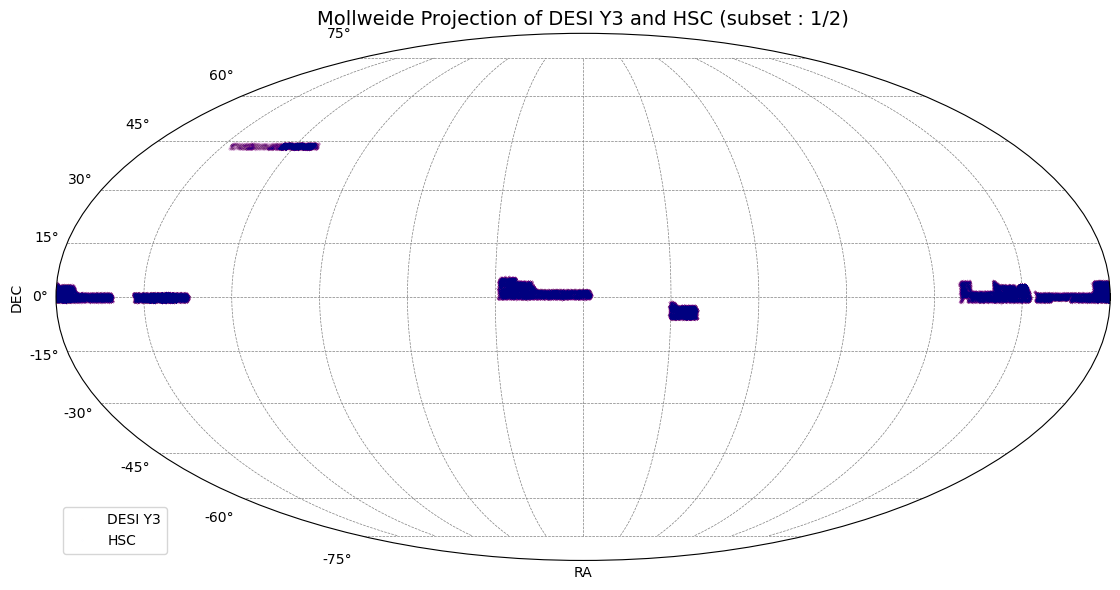

In [15]:
# Plotting the coordinates of the matched catalogs
sample_rate = 2
# Wrap RA coordinates to [-pi, pi]
ra_desi_wr = np.remainder(ra_desi[0::sample_rate] + np.pi, 2 * np.pi) - np.pi
ra_hsc_wr = np.remainder(ra_hsc[0::sample_rate] + np.pi, 2 * np.pi) - np.pi

plt.figure(figsize=(12, 6))
ax = plt.subplot(111, projection="mollweide")
ax.plot(
    ra_desi_wr,
    dec_desi[0::sample_rate],
    "r.",
    markersize=0.03,
    label="DESI Y3",
    alpha=0.3,
)
print(f"Finished plotting DESI coordinates")
ax.plot(
    ra_hsc_wr, dec_hsc[0::sample_rate], "b.", markersize=0.03, label="HSC", alpha=0.3
)
print(f"Finished plotting HSC coordinates")

ax.grid(color="gray", linestyle="--", linewidth=0.5)
ax.set_xticklabels([])
ax.legend(loc="lower left", fontsize=10)
ax.set_xlabel("RA")
ax.set_ylabel("DEC")
plt.title(
    f"Mollweide Projection of DESI Y3 and HSC (subset : 1/{sample_rate})", fontsize=14
)
plt.tight_layout()
plt.show()

In [16]:
## Let's zoom on a specifc region of the crossmatch
bounds = [
    [179, 181],  # RA
    [1, 3],  # DEC
]


def spatial_bounds(coords, bounds):
    """
    Function to select coordinates based on spatial bounds
    """
    ra = coords.ra.deg
    dec = coords.dec.deg
    mask = ((ra > bounds[0][0]) & (ra < bounds[0][1])) & (
        (dec > bounds[1][0]) & (dec < bounds[1][1])
    )
    return mask

In [17]:
# Compute xmatch bounded coords
desi_xmatch_coords_b = coords_xmatch_desi[spatial_bounds(coords_xmatch_desi, bounds)]
hsc_xmatch_coords_b = coords_xmatch_hsc[spatial_bounds(coords_xmatch_hsc, bounds)]

In [37]:
# Compute full sample bounded coords
desi_coords_b = coords_desi[spatial_bounds(coords_desi, bounds)]
hsc_coords_b = coords_hsc[spatial_bounds(coords_hsc, bounds)]

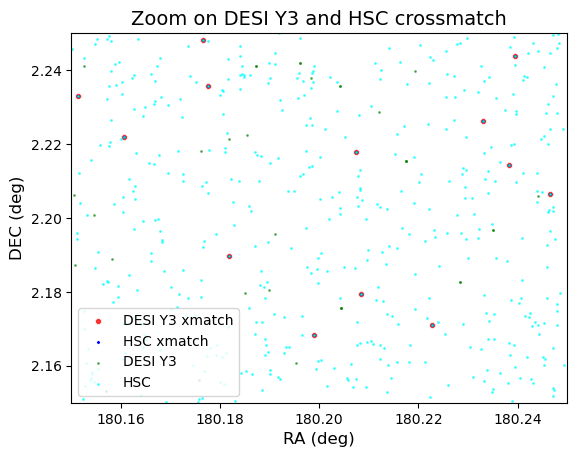

In [38]:
sample_rate_b = 2
center_ra = bounds[0][0] + (bounds[0][1] - bounds[0][0]) / 2
center_dec = bounds[1][0] + (bounds[1][1] - bounds[1][0]) / 2
zoom = 0.05
offset = 0.2
bds_ra = [center_ra - zoom + offset, center_ra + zoom + offset]
bds_dec = [center_dec - zoom + offset, center_dec + zoom + offset]
plt.xlim(bds_ra[0], bds_ra[1])
plt.ylim(bds_dec[0], bds_dec[1])


def set_range(coords, bds_x, bds_y):
    ra = coords.ra.deg
    dec = coords.dec.deg
    mask = ((ra > bds_x[0]) & (ra < bds_x[1])) & ((dec > bds_y[0]) & (dec < bds_y[1]))
    return ra[mask], dec[mask]


ra_desi_xmatch, dec_desi_xmatch = set_range(desi_xmatch_coords_b, bds_ra, bds_dec)
ra_hsc_xmatch, dec_hsc_xmatch = set_range(hsc_xmatch_coords_b, bds_ra, bds_dec)
ra_desi, dec_desi = set_range(desi_coords_b, bds_ra, bds_dec)
ra_hsc, dec_hsc = set_range(hsc_coords_b, bds_ra, bds_dec)

plt.scatter(
    ra_desi_xmatch,
    dec_desi_xmatch,
    color="red",
    marker="P",
    s=5,
    label="DESI Y3 xmatch",
    alpha=0.7,
)
plt.scatter(
    ra_hsc_xmatch,
    dec_hsc_xmatch,
    color="blue",
    marker="D",
    s=1,
    label="HSC xmatch",
    alpha=1,
)
plt.scatter(
    ra_desi, dec_desi, color="green", marker="X", s=1, label="DESI Y3", alpha=0.5
)
plt.scatter(ra_hsc, dec_hsc, color="cyan", marker="X", s=1, label="HSC", alpha=0.6)
plt.xlabel("RA (deg)", fontsize=12)
plt.ylabel("DEC (deg)", fontsize=12)
plt.title(f"Zoom on DESI Y3 and HSC crossmatch", fontsize=14)
plt.legend(loc="lower left", fontsize=10)

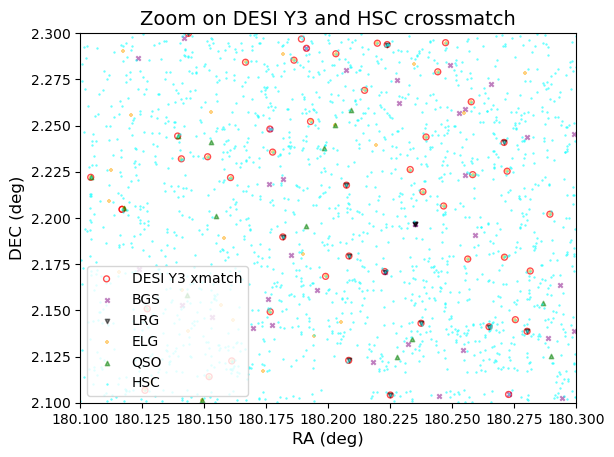

In [63]:
center_ra = bounds[0][0] + (bounds[0][1] - bounds[0][0]) / 2
center_dec = bounds[1][0] + (bounds[1][1] - bounds[1][0]) / 2
zoom = 0.1
offset = 0.2
bds_ra = [center_ra - zoom + offset, center_ra + zoom + offset]
bds_dec = [center_dec - zoom + offset, center_dec + zoom + offset]
plt.xlim(bds_ra[0], bds_ra[1])
plt.ylim(bds_dec[0], bds_dec[1])

ra_desi_xmatch, dec_desi_xmatch = set_range(desi_xmatch_coords_b, bds_ra, bds_dec)
ra_hsc_xmatch, dec_hsc_xmatch = set_range(hsc_xmatch_coords_b, bds_ra, bds_dec)
ra_desi, dec_desi = set_range(desi_coords_b, bds_ra, bds_dec)
ra_hsc, dec_hsc = set_range(hsc_coords_b, bds_ra, bds_dec)

plt.scatter(
    ra_desi_xmatch,
    dec_desi_xmatch,
    facecolors="none",
    edgecolors="red",
    linewidths=1,
    s=18,
    label="DESI Y3 xmatch",
    alpha=0.7,
    marker="o",
)
from desitarget.targetmask import desi_mask

desi_tgt = desi["DESI_TARGET"][spatial_bounds(coords_desi, bounds)]

is_bgs = desi_tgt & desi_mask.BGS_ANY != 0  # - instead of 2**60
is_lrg = desi_tgt & desi_mask.LRG != 0
is_elg = desi_tgt & desi_mask.ELG != 0
is_qso = desi_tgt & desi_mask.QSO != 0
is_mws = desi_tgt & desi_mask.MWS_ANY != 0
is_scnd = desi_tgt & desi_mask.SCND_ANY != 0
masks = {
    "BGS": is_bgs,
    "LRG": is_lrg,
    "ELG": is_elg,
    "QSO": is_qso,
    #'MWS': is_mws,
    #'SCND': is_scnd
}

colors = ["purple", "black", "orange", "green"]
markers = ["x", "v", "+", "^"]
for i, (key, mask) in enumerate(masks.items()):
    # print(f'Number of {key} targets : {len(desi[mask])}')
    ra_desi_mask, dec_desi_mask = set_range(desi_coords_b[mask], bds_ra, bds_dec)
    plt.scatter(
        ra_desi_mask,
        dec_desi_mask,
        marker=markers[i],
        s=10,
        color=colors[i],
        label=f"{key}",
        alpha=0.5,
    )
plt.scatter(ra_hsc, dec_hsc, color="cyan", marker="X", s=0.6, label="HSC", alpha=0.4)
plt.xlabel("RA (deg)", fontsize=12)
plt.ylabel("DEC (deg)", fontsize=12)
plt.title(f"Zoom on DESI Y3 and HSC crossmatch", fontsize=14)
plt.legend(loc="lower left", fontsize=10)